In [6]:
import pandas as pd
import numpy as np

In [7]:
file_path = "/content/collegePlace.csv"
df = pd.read_csv(file_path)

In [8]:
print("first 05 rows:")
print(df.head())

first 05 rows:
   Age  Gender                         Stream  Internships  CGPA  Hostel  \
0   22    Male  Electronics And Communication            1     8       1   
1   21  Female               Computer Science            0     7       1   
2   22  Female         Information Technology            1     6       0   
3   21    Male         Information Technology            0     8       0   
4   22    Male                     Mechanical            0     8       1   

   HistoryOfBacklogs  PlacedOrNot  
0                  1            1  
1                  1            1  
2                  0            1  
3                  1            1  
4                  0            1  


In [9]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2966 entries, 0 to 2965
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Age                2966 non-null   int64 
 1   Gender             2966 non-null   object
 2   Stream             2966 non-null   object
 3   Internships        2966 non-null   int64 
 4   CGPA               2966 non-null   int64 
 5   Hostel             2966 non-null   int64 
 6   HistoryOfBacklogs  2966 non-null   int64 
 7   PlacedOrNot        2966 non-null   int64 
dtypes: int64(6), object(2)
memory usage: 185.5+ KB
None


In [10]:
print("\nSummary Statistics:")
print(df.describe(include='all'))


Summary Statistics:
                Age Gender            Stream  Internships         CGPA  \
count   2966.000000   2966              2966  2966.000000  2966.000000   
unique          NaN      2                 6          NaN          NaN   
top             NaN   Male  Computer Science          NaN          NaN   
freq            NaN   2475               776          NaN          NaN   
mean      21.485840    NaN               NaN     0.703641     7.073837   
std        1.324933    NaN               NaN     0.740197     0.967748   
min       19.000000    NaN               NaN     0.000000     5.000000   
25%       21.000000    NaN               NaN     0.000000     6.000000   
50%       21.000000    NaN               NaN     1.000000     7.000000   
75%       22.000000    NaN               NaN     1.000000     8.000000   
max       30.000000    NaN               NaN     3.000000     9.000000   

             Hostel  HistoryOfBacklogs  PlacedOrNot  
count   2966.000000        2966.0000

In [11]:
print("Missing Values in each column:")
print(df.isnull().sum())


Missing Values in each column:
Age                  0
Gender               0
Stream               0
Internships          0
CGPA                 0
Hostel               0
HistoryOfBacklogs    0
PlacedOrNot          0
dtype: int64


In [12]:
duplicate_rows = df.duplicated().sum()
print(f"\nNumber of duplicated rows: {duplicate_rows}")


Number of duplicated rows: 1829


In [13]:
if duplicate_rows > 0:
  df = df.drop_duplicates()
  print("Duplicate rows removed")

Duplicate rows removed


In [14]:
print("\nColumn Data Types:")
print(df.dtypes)
print("\nUnique Values in each column:")
for column in df.columns:
  print(f"{column}:{df[column].unique()}")


Column Data Types:
Age                   int64
Gender               object
Stream               object
Internships           int64
CGPA                  int64
Hostel                int64
HistoryOfBacklogs     int64
PlacedOrNot           int64
dtype: object

Unique Values in each column:
Age:[22 21 23 24 28 30 25 26 20 19 29]
Gender:['Male' 'Female']
Stream:['Electronics And Communication' 'Computer Science'
 'Information Technology' 'Mechanical' 'Electrical' 'Civil']
Internships:[1 0 2 3]
CGPA:[8 7 6 9 5]
Hostel:[1 0]
HistoryOfBacklogs:[1 0]
PlacedOrNot:[1 0]


In [15]:
print("Data types before encoding:")
print(df.dtypes)

categorical_cols = df.select_dtypes(include='object').columns
print("\nCategorical columns to encode:", list(categorical_cols))

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])
    print(f"Encoded column: {col}")


Data types before encoding:
Age                   int64
Gender               object
Stream               object
Internships           int64
CGPA                  int64
Hostel                int64
HistoryOfBacklogs     int64
PlacedOrNot           int64
dtype: object

Categorical columns to encode: ['Gender', 'Stream']
Encoded column: Gender
Encoded column: Stream


# Exploratory Data Analysis

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
sns.set(style='whitegrid')

In [18]:
print("Value counts for target variable (placement status):")
df.rename(columns={'PlacedOrNot': 'status'}, inplace=True)
print(df['status'].value_counts())

Value counts for target variable (placement status):
status
1    659
0    478
Name: count, dtype: int64


<ipython-input-19-5c389b0a6a3c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='status', palette='Set2')


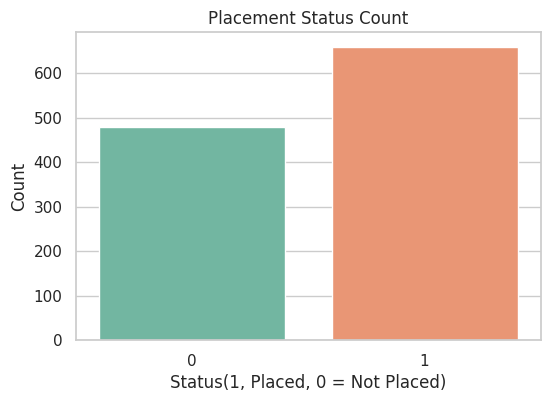

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='status', palette='Set2')
plt.title("Placement Status Count")
plt.xlabel("Status(1, Placed, 0 = Not Placed)")
plt.ylabel("Count")
plt.show()

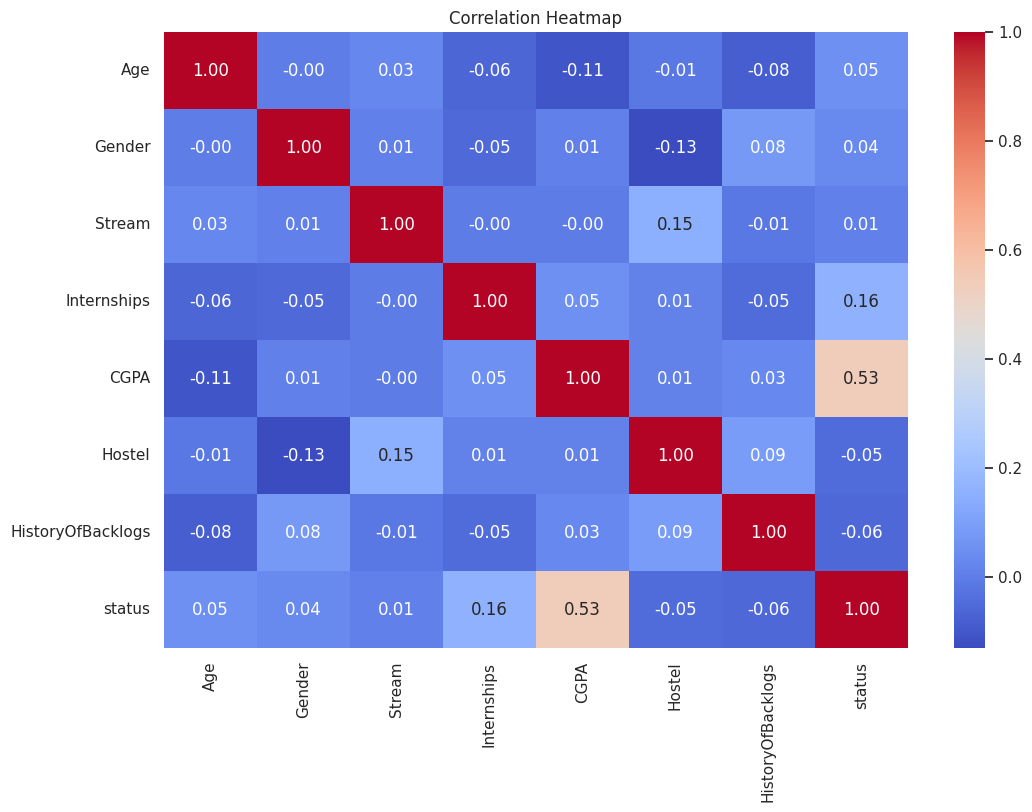

In [20]:
plt.figure(figsize=(12,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

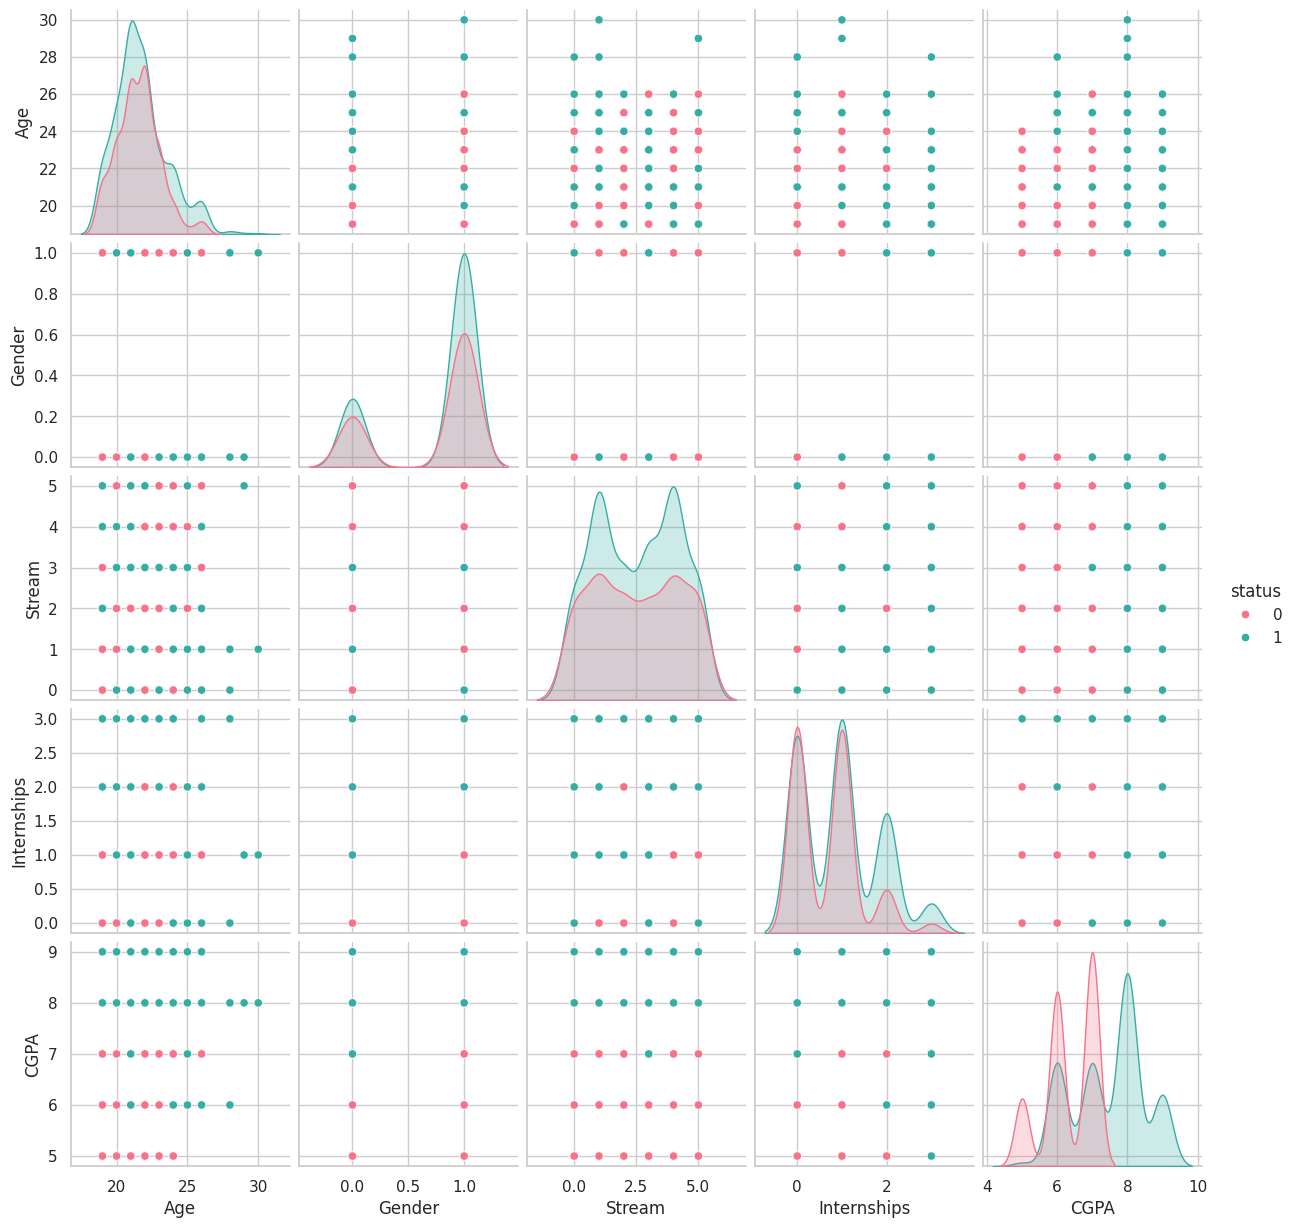

In [21]:
selected_features = ['Age', 'Gender', 'Stream', 'Internships', 'CGPA', 'status']
sns.pairplot(df[selected_features], hue='status', palette='husl')
plt.show()

<ipython-input-22-151dda0a5766>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='CGPA', palette='Set3')


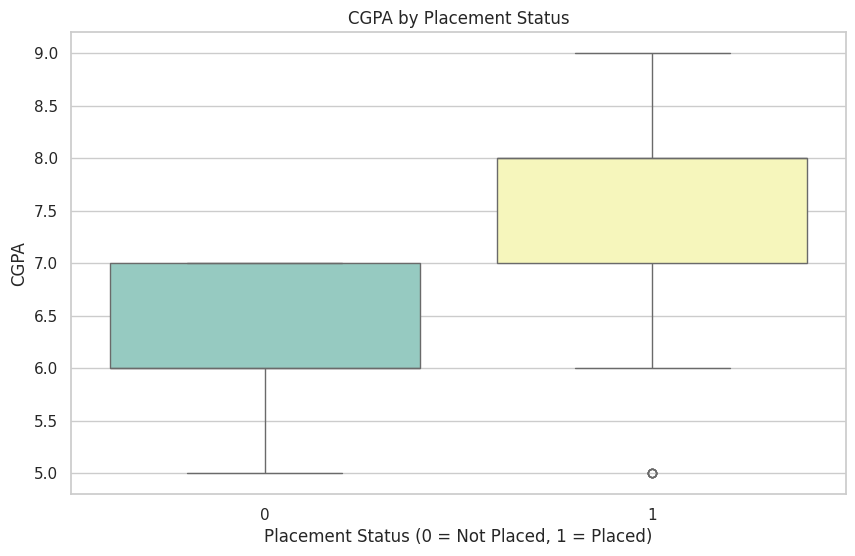

<ipython-input-22-151dda0a5766>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='status', y='Internships', palette='Set2')


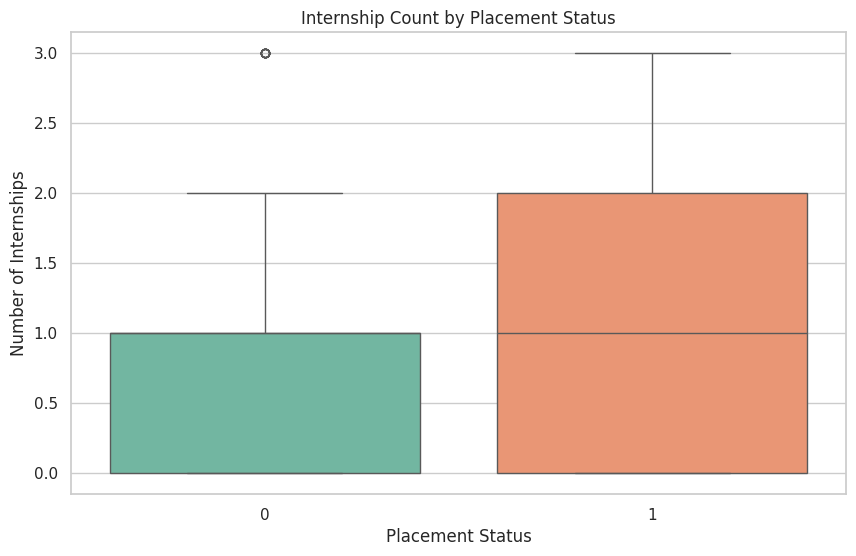

In [22]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='status', y='CGPA', palette='Set3')
plt.title('CGPA by Placement Status')
plt.xlabel("Placement Status (0 = Not Placed, 1 = Placed)")
plt.ylabel("CGPA")
plt.show()



plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='status', y='Internships', palette='Set2')
plt.title('Internship Count by Placement Status')
plt.xlabel("Placement Status")
plt.ylabel("Number of Internships")
plt.show()

# Feature Engineering

In [23]:
x = df.drop('status',axis=1)
y = df['status']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)
X_scaled = pd.DataFrame(X_scaled, columns=x.columns)
print("Scaled Features:")
print(X_scaled.head())

Scaled Features:
        Age    Gender    Stream  Internships      CGPA    Hostel  \
0  0.209254  0.586491  0.279220     0.178784  0.947780  1.408635   
1 -0.373887 -1.705056 -0.921057    -1.024040  0.010714  1.408635   
2  0.209254 -1.705056  0.879358     0.178784 -0.926352 -0.709907   
3 -0.373887  0.586491  0.879358    -1.024040  0.947780 -0.709907   
4  0.209254  0.586491  1.479497    -1.024040  0.947780  1.408635   

   HistoryOfBacklogs  
0           1.540742  
1           1.540742  
2          -0.649038  
3           1.540742  
4          -0.649038  


# Model Selection And Training

In [59]:
import lightgbm as lgb
from lightgbm import early_stopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


X = df.drop('status', axis=1)
y = df['status']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the LightGBM dataset
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

# Set parameters
params = {
    'objective': 'binary',          # Binary classification
    'metric': 'binary_error',       # Evaluation metric
    'boosting_type': 'gbdt',        # Gradient Boosting Decision Tree
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9
}

# Train the model with early stopping callback
gbm = lgb.train(
    params,
    train_data,
    num_boost_round=100,
    valid_sets=[test_data],
    callbacks=[early_stopping(stopping_rounds=10)]
)

# Make predictions
y_pred = gbm.predict(X_test, num_iteration=gbm.best_iteration)
y_pred_binary = (y_pred >= 0.5).astype(int)  # Convert probabilities to binary labels

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred_binary)
print(f"Accuracy: {accuracy:.4f}")


[LightGBM] [Info] Number of positive: 521, number of negative: 388
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000127 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 33
[LightGBM] [Info] Number of data points in the train set: 909, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.573157 -> initscore=0.294745
[LightGBM] [Info] Start training from score 0.294745
Training until validation scores don't improve for 10 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warni

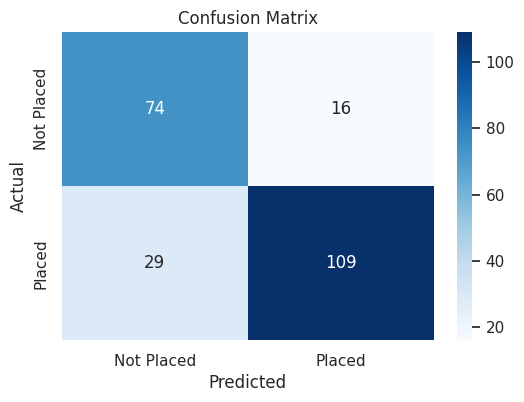

In [60]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred_binary)
labels = ['Not Placed', 'Placed']

# Plot using seaborn heatmap
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


# Model Comparison and Tuning

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define models to compare
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

# Evaluate each model
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print(f"\n Model: {name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("-" * 50)

# Summarize all results
df_results = pd.DataFrame(results, columns=["Model", "Accuracy"])
print("\n Accuracy Comparison:\n")
print(df_results.sort_values(by="Accuracy", ascending=False))



 Model: Logistic Regression
Accuracy: 0.7324561403508771
Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.65      0.67        96
           1       0.76      0.80      0.77       132

    accuracy                           0.73       228
   macro avg       0.73      0.72      0.72       228
weighted avg       0.73      0.73      0.73       228

--------------------------------------------------

 Model: Decision Tree
Accuracy: 0.7850877192982456
Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.83      0.77        96
           1       0.86      0.75      0.80       132

    accuracy                           0.79       228
   macro avg       0.78      0.79      0.78       228
weighted avg       0.80      0.79      0.79       228

--------------------------------------------------

 Model: Random Forest
Accuracy: 0.7543859649122807
Classification Report:
           

# Model Evaluation

In [61]:
from sklearn.metrics import classification_report, roc_auc_score, roc_curve

# Classification report
print(classification_report(y_test, y_pred_binary))

# ROC AUC
y_pred_proba = gbm.predict(X_test)
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC Score: {auc_score:.4f}")


              precision    recall  f1-score   support

           0       0.72      0.82      0.77        90
           1       0.87      0.79      0.83       138

    accuracy                           0.80       228
   macro avg       0.80      0.81      0.80       228
weighted avg       0.81      0.80      0.80       228

AUC Score: 0.8897


# Feature Importance Visualization

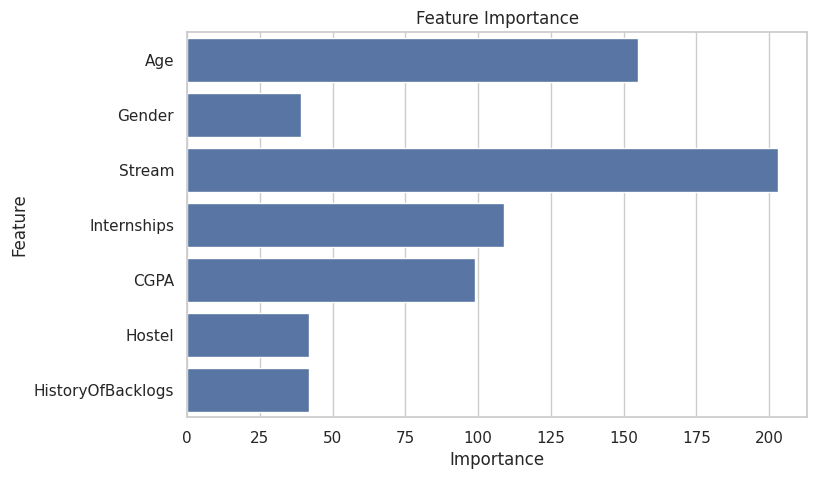

In [62]:
importances = gbm.feature_importance()
features = X.columns

plt.figure(figsize=(8, 5))
sns.barplot(x=importances, y=features)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


# Saving Model

In [63]:
import joblib
joblib.dump(gbm, 'placement_model.pkl')


['placement_model.pkl']

# Interface Pipeline

In [64]:
def predict_placement(input_data, model):
    df_input = pd.DataFrame([input_data])
    return model.predict(df_input)[0]


In [66]:
import joblib
model_filename = 'placement_model.pkl'
joblib.dump(gbm, model_filename)

from google.colab import files
files.download('placement_model.pkl')



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>